# 02 — Analyse rule sensitivity and card effectiveness

This notebook analyses the saved rule-sensitivity simulations generated by `01_run_rule_sensitivity.ipynb`.

The analysis addresses two related questions:

1. **Rule sensitivity:** how does the size and structure of the choice set affect cautious versus greedy players?
2. **Card robustness:** which cards remain associated with good outcomes across different card-access and passing rules?

Victory points (`vp`) represent the game's CO₂ score. **Lower VP is better.**


## 1. Load the experiment

The notebook uses the combined Parquet files created by the run notebook. The individual condition folders remain available for debugging or rerunning specific conditions.


In [2]:
%cd ../../..

c:\Users\schneids\code\KlimSta-Brettspiel


In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from model.game import load_game_data
from model.analysis import card_analysis


VERSION = Path("Versionen/paper_draft_v1")
EXPERIMENT_DIR = VERSION / "results" / "rule_sensitivity"
CARD_RESULTS_PATH = EXPERIMENT_DIR / "card_results.parquet"
RECALCULATE_CARD_RESULTS = False

game_data = load_game_data(VERSION)

all_games_raw = pd.read_parquet(
    EXPERIMENT_DIR / "all_games.parquet"
)

all_plays_raw = pd.read_parquet(
    EXPERIMENT_DIR / "all_plays.parquet"
)
MAX_ROUNDS = game_data["board"]["max_rounds"]

all_games = all_games_raw.loc[
    (all_games_raw["rounds_played"] == MAX_ROUNDS)
    & (all_games_raw["budget"] >= 0)
].copy()

completed_ids = all_games[
    ["experiment", "game_id"]
].drop_duplicates()

all_plays = all_plays_raw.merge(
    completed_ids,
    on=["experiment", "game_id"],
    how="inner",
)
design = pd.read_csv(
    EXPERIMENT_DIR / "design.csv"
)

print(f"{len(all_games):,} games")
print(f"{len(all_plays):,} logged decisions")
print(f"{all_games['experiment'].nunique()} conditions")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
171,480 games
1,460,666 logged decisions
20 conditions


In [4]:
completion_summary = (
    all_games_raw
    .groupby(["access_rule", "pass_probability"])
    .agg(
        total_games=("game_id", "size"),
        completed_games=(
            "rounds_played",
            lambda x: (x == MAX_ROUNDS).sum(),
        ),
    )
    .reset_index()
)

completion_summary["completion_rate"] = (
    completion_summary["completed_games"]
    / completion_summary["total_games"]
)
completion_summary

,access_rule,pass_probability,total_games,completed_games,completion_rate
0,category_1x3,0.00,10000,8932,0.8932
1,category_1x3,0.10,10000,9025,0.9025
2,category_1x3,0.25,10000,9222,0.9222
3,category_1x3,0.50,10000,9532,0.9532
4,category_2x3,0.00,10000,8591,0.8591
5,category_2x3,0.10,10000,8718,0.8718
6,category_2x3,0.25,10000,8909,0.8909
7,category_2x3,0.50,10000,9324,0.9324
8,random_10,0.00,10000,8218,0.8218
9,random_10,0.10,10000,8369,0.8369


## 2. Overall outcome summary

First inspect whether the gameplay rules materially change the game.

The summary includes:

- mean and median final VP,
- dispersion of VP,
- remaining budget,
- number of cards played,
- share of games completing all four rounds.

The number of cards played is particularly important because passing probability directly affects how aggressively the simulated player continues selecting cards.


In [5]:
summary = (
    all_games
    .groupby(["access_rule", "pass_probability"])
    .agg(
        games=("game_id", "size"),
        mean_vp=("vp", "mean"),
        median_vp=("vp", "median"),
        std_vp=("vp", "std"),
        mean_budget=("budget", "mean"),
        mean_cards=("n_cards_played", "mean"),
        completed_share=(
            "rounds_played",
            lambda x: (x == 4).mean(),
        ),
    )
    .reset_index()
)

summary.to_csv(
    EXPERIMENT_DIR / "summary.csv",
    index=False,
)

summary


,access_rule,pass_probability,games,mean_vp,median_vp,std_vp,mean_budget,mean_cards,completed_share
0,category_1x3,0.00,8770,446.151995,453.0,231.001574,5.595325,5.900570,1.0
1,category_1x3,0.10,8869,483.680573,506.0,232.415111,5.689367,5.221107,1.0
2,category_1x3,0.25,9070,544.354576,599.0,231.698945,5.939140,4.159757,1.0
3,category_1x3,0.50,9426,650.870040,739.0,215.641933,6.540208,2.486208,1.0
4,category_2x3,0.00,8424,369.131648,341.0,221.800934,4.743234,8.398504,1.0
5,category_2x3,0.10,8556,407.146330,399.0,224.657630,4.921926,7.409420,1.0
6,category_2x3,0.25,8734,478.367644,493.0,231.441435,5.268605,5.773872,1.0
7,category_2x3,0.50,9163,611.844374,684.0,224.676888,6.231256,3.174288,1.0
8,random_10,0.00,8038,305.656631,244.0,216.325088,3.930455,10.638343,1.0
9,random_10,0.10,8159,351.418679,308.0,225.874847,4.273931,9.144258,1.0


## 3. Choice set × passing behaviour

The following pivot tables are the core rule-sensitivity results.

Read each row as one player type:

- `0.00`: never voluntarily passes; most greedy
- `0.10`: low probability of stopping
- `0.25`: intermediate
- `0.50`: frequently stops; most cautious

The columns vary what cards are available to choose from.


In [6]:
vp_table = all_games.pivot_table(
    index="pass_probability",
    columns="access_rule",
    values="vp",
    aggfunc="mean",
)

vp_table


access_rule,category_1x3,category_2x3,random_10,random_20,random_30
pass_probability,,,,,
0.00,446.151995,369.131648,305.656631,303.357661,290.514150
0.10,483.680573,407.146330,351.418679,346.215710,338.754382
0.25,544.354576,478.367644,427.705307,425.747284,425.635591
0.50,650.870040,611.844374,582.429772,579.061157,584.895442


In [7]:
cards_played_table = all_games.pivot_table(
    index="pass_probability",
    columns="access_rule",
    values="n_cards_played",
    aggfunc="mean",
)

cards_played_table


access_rule,category_1x3,category_2x3,random_10,random_20,random_30
pass_probability,,,,,
0.00,5.900570,8.398504,10.638343,11.615471,12.016581
0.10,5.221107,7.409420,9.144258,10.214849,10.711800
0.25,4.159757,5.773872,6.809183,7.546735,7.913475
0.50,2.486208,3.174288,3.451165,3.579770,3.649799


### Mean final VP

A lower line means better average game performance.

The comparison within each pass probability answers the main question: **how much does broader or differently structured card access matter for players with the same stopping behaviour?**


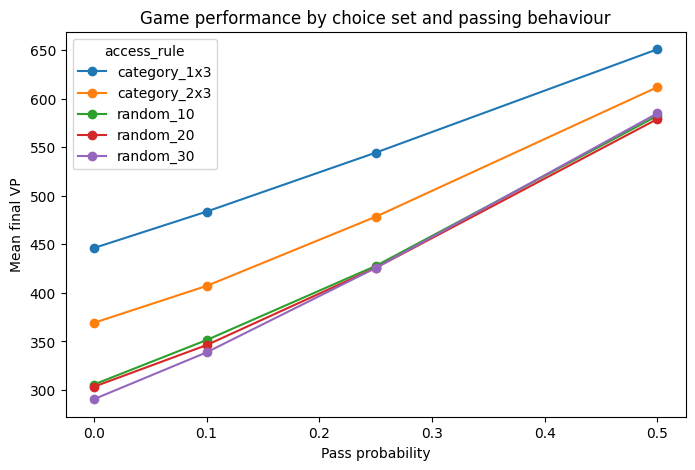

In [8]:
ax = vp_table.plot(
    marker="o",
    figsize=(8, 5),
)

ax.set_xlabel("Pass probability")
ax.set_ylabel("Mean final VP")
ax.set_title("Game performance by choice set and passing behaviour")

plt.show()


### Mean number of cards played

This plot helps interpret the VP result. If one rule produces better VP primarily because it causes players to select many more cards, that should be visible here.


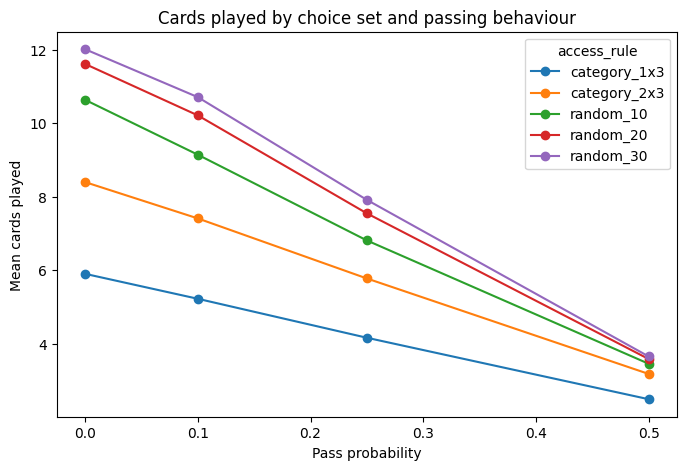

In [9]:
ax = cards_played_table.plot(
    marker="o",
    figsize=(8, 5),
)

ax.set_xlabel("Pass probability")
ax.set_ylabel("Mean cards played")
ax.set_title("Cards played by choice set and passing behaviour")

plt.show()


## 4. Card effectiveness within each condition

Card effectiveness should **not** be estimated from all 200,000 games pooled together.

The access rules directly change the probability that a card is offered and playable. `card_analysis()` is therefore calculated separately for each of the 20 experimental conditions.

The main card metrics are:

- `occurrence`: fraction of games containing the card,
- `elite_occurrence`: fraction of the best 5% of games containing it,
- `enrichment`: elite occurrence divided by overall occurrence,
- `vp_lift`: mean VP without the card minus mean VP with it; **positive is better**,
- `selection_rate`: selection frequency conditional on being playable.

These remain descriptive associations rather than causal card effects.


In [10]:
if CARD_RESULTS_PATH.exists() and not RECALCULATE_CARD_RESULTS:

    card_results = pd.read_parquet(CARD_RESULTS_PATH)
    print("Loaded cached card results.")

else:

    # Only completed games enter VP/card-effectiveness analysis.
    completed_games = all_games.loc[
        all_games["completed"]
    ].copy()

    # Prepare play groups once instead of scanning all_plays 20 times.
    plays_by_experiment = {
        experiment: plays
        for experiment, plays in all_plays.groupby("experiment")
    }

    card_results = []

    for experiment, games in completed_games.groupby("experiment"):

        # Keep only plays belonging to completed games.
        valid_game_ids = games["game_id"]

        plays = plays_by_experiment[experiment]

        plays = plays.loc[
            plays["game_id"].isin(valid_game_ids)
        ]

        print(experiment)

        result = card_analysis(
            games,
            plays=plays,
            game_data=game_data,
            elite_share=0.05,
        )

        result["experiment"] = experiment
        result["access_rule"] = games["access_rule"].iloc[0]
        result["pass_probability"] = games["pass_probability"].iloc[0]

        card_results.append(result)

    card_results = pd.concat(
        card_results,
        ignore_index=True,
    )

    card_results.to_parquet(
        CARD_RESULTS_PATH,
        index=False,
    )

    print("Card results calculated and cached.")


Loaded cached card results.


## 5. What the card metrics mean

No single metric should be read as "the value of a card". The simulation provides several complementary signals.

### Occurrence

`occurrence` is the share of games in which the card was played.

It measures **exposure**, not effectiveness. A card can be common because it is cheap, appears often in the physical deck, has few prerequisites, or is available under many rules.

### VP lift

`vp_lift` compares the final VP of games with and without the card:
```math
VP\ lift =
\overline{VP}_{without}
-
\overline{VP}_{with}
```

Because lower VP is better, **positive VP lift is favourable**.

This is still an association. Cards can appear in better games because of prerequisites, combinations with other cards, or the states in which they become playable.

### Elite enrichment

`enrichment` compares occurrence in the best 5% of games with occurrence in all games:

```math
enrichment =
\frac{P(card \mid elite)}
     {P(card)}
```

- `1`: neutral
- `> 1`: overrepresented among elite games
- `< 1`: underrepresented among elite games

Enrichment is useful because it normalises for overall occurrence, but it becomes unstable for very rare cards.

### Robustness across rules

`positive_lift_share` is the share of rule conditions with an estimable positive VP lift.

`enriched_share` is the share of rule conditions with enrichment above 1.

These are especially important here because the 20 rule conditions deliberately alter card access and passing behaviour.

### Selection rate

`selection_rate = selected / playable opportunities`.

Under the current **random card-selection strategy**, this is **not a preference metric**. It mainly indicates how much competition a card faces when it is playable. A card offered alongside many alternatives has a lower chance of random selection.

### Mean round

`mean_round` describes timing. Early cards can influence more subsequent rounds and can unlock prerequisites, so timing helps explain why occurrence and VP lift may differ.


In [11]:
# Weighted timing needs the number of plays in each condition.
card_results["round_weight"] = (
    card_results["mean_round"]
    * card_results["times_played"]
)

card_robustness = (
    card_results
    .groupby(["card", "label_en"])
    .agg(
        conditions=("experiment", "nunique"),

        mean_occurrence=("occurrence", "mean"),
        min_occurrence=("occurrence", "min"),
        max_occurrence=("occurrence", "max"),

        mean_vp_lift=("vp_lift", "mean"),
        min_vp_lift=("vp_lift", "min"),
        max_vp_lift=("vp_lift", "max"),

        lift_estimable=("vp_lift", lambda x: x.notna().sum()),
        positive_lift_cases=("vp_lift", lambda x: (x > 0).sum()),

        mean_enrichment=("enrichment", "mean"),
        min_enrichment=("enrichment", "min"),
        max_enrichment=("enrichment", "max"),
        enriched_cases=("enrichment", lambda x: (x > 1).sum()),

        playable_opportunities=("playable_opportunities", "sum"),
        selected=("selected", "sum"),
        times_played=("times_played", "sum"),
        round_weight=("round_weight", "sum"),
    )
    .reset_index()
)

# Robustness across rule conditions.
card_robustness["positive_lift_share"] = (
    card_robustness["positive_lift_cases"]
    / card_robustness["lift_estimable"].replace(0, pd.NA)
)

card_robustness["enriched_share"] = (
    card_robustness["enriched_cases"]
    / card_robustness["conditions"]
)

# Opportunity-adjusted summaries across all rule conditions.
card_robustness["selection_rate"] = (
    card_robustness["selected"]
    / card_robustness["playable_opportunities"].replace(0, pd.NA)
)

card_robustness["mean_round"] = (
    card_robustness["round_weight"]
    / card_robustness["times_played"].replace(0, pd.NA)
)

card_robustness = card_robustness.sort_values(
    ["positive_lift_share", "mean_vp_lift"],
    ascending=False,
)

card_robustness.to_csv(
    EXPERIMENT_DIR / "card_robustness.csv",
    index=False,
)

card_robustness


,card,label_en,conditions,mean_occurrence,min_occurrence,max_occurrence,mean_vp_lift,min_vp_lift,max_vp_lift,lift_estimable,...,max_enrichment,enriched_cases,playable_opportunities,selected,times_played,round_weight,positive_lift_share,enriched_share,selection_rate,mean_round
46,thermal_flexibility,Thermal flexibility,20,0.177892,0.007851,0.514524,279.192071,223.866096,389.590734,20,...,8.654157,20,90446,29276,29276,73080.0,1.00,1.00,0.323685,2.496243
44,shower_water_heat_recovery,Heat recovery from shower water,20,0.067822,0.006684,0.163571,276.808935,189.777155,427.920584,20,...,9.529876,20,83813,11229,11229,34790.0,1.00,1.00,0.133977,3.098228
16,efficient_appliances,Efficient appliances,20,0.069450,0.006047,0.159830,265.719935,186.546868,371.608423,20,...,7.724215,20,83466,11503,11503,35701.0,1.00,1.00,0.137817,3.103625
50,wastewater_heat_pump,Wastewater heat pumps,20,0.054047,0.035328,0.063447,207.727735,138.550155,318.133009,20,...,5.223933,20,117283,9215,9215,19248.0,1.00,1.00,0.078571,2.088768
28,groundwater_heat_pump,Groundwater heat pump,20,0.077708,0.036283,0.103478,204.185350,117.159289,321.369344,20,...,5.141870,20,157899,13162,13162,28333.0,1.00,1.00,0.083357,2.152636
13,decentralized_air_source_heat_pump,Decentralized air source heat pump,20,0.129951,0.047104,0.201169,200.912479,103.850049,340.581633,20,...,5.724364,20,196971,21867,21867,46946.0,1.00,1.00,0.111016,2.146888
24,geothermal_heat_pump,Geothermal heat pump,20,0.078611,0.036813,0.105724,191.977658,115.255667,326.781723,20,...,5.536666,20,158463,13314,13314,28632.0,1.00,1.00,0.084020,2.150518
9,central_air_source_heat_pump,Central air source heat pump,20,0.077800,0.037662,0.102232,191.086203,108.291016,323.492793,20,...,4.679035,20,157636,13176,13176,28515.0,1.00,1.00,0.083585,2.164162
6,biomass_boiler,Biomass boiler,20,0.129031,0.044770,0.205710,117.432118,14.988304,257.073478,20,...,0.284541,0,197219,21697,21697,46411.0,1.00,0.00,0.110015,2.139051
29,insulation_passivehouse_eco,Passivehouse renovation ecological,20,0.039410,0.029049,0.047034,115.062496,80.331465,174.746844,20,...,2.105783,19,91709,6769,6769,14039.0,1.00,0.95,0.073810,2.074014


## 6. Robust card candidates

A card is more convincing when several signals agree:

- VP lift is positive,
- elite enrichment is above 1,
- these patterns persist across rule conditions,
- the card occurs often enough to estimate the comparison.

The table below uses `positive_lift_share >= 0.75` only as a **screening rule**, not as a statistical significance threshold.


In [12]:
robust_candidates = card_robustness.loc[
    (card_robustness["lift_estimable"] > 0)
    & (card_robustness["positive_lift_share"] >= 0.75)
].copy()

robust_candidates[
    [
        "card",
        "label_en",
        "mean_occurrence",
        "mean_vp_lift",
        "min_vp_lift",
        "max_vp_lift",
        "positive_lift_share",
        "mean_enrichment",
        "enriched_share",
    ]
]


,card,label_en,mean_occurrence,mean_vp_lift,min_vp_lift,max_vp_lift,positive_lift_share,mean_enrichment,enriched_share
46,thermal_flexibility,Thermal flexibility,0.177892,279.192071,223.866096,389.590734,1.00,3.931437,1.00
44,shower_water_heat_recovery,Heat recovery from shower water,0.067822,276.808935,189.777155,427.920584,1.00,4.816319,1.00
16,efficient_appliances,Efficient appliances,0.069450,265.719935,186.546868,371.608423,1.00,4.105881,1.00
50,wastewater_heat_pump,Wastewater heat pumps,0.054047,207.727735,138.550155,318.133009,1.00,3.238386,1.00
28,groundwater_heat_pump,Groundwater heat pump,0.077708,204.185350,117.159289,321.369344,1.00,3.318320,1.00
13,decentralized_air_source_heat_pump,Decentralized air source heat pump,0.129951,200.912479,103.850049,340.581633,1.00,2.263491,1.00
24,geothermal_heat_pump,Geothermal heat pump,0.078611,191.977658,115.255667,326.781723,1.00,2.547161,1.00
9,central_air_source_heat_pump,Central air source heat pump,0.077800,191.086203,108.291016,323.492793,1.00,1.988377,1.00
6,biomass_boiler,Biomass boiler,0.129031,117.432118,14.988304,257.073478,1.00,0.098242,0.00
29,insulation_passivehouse_eco,Passivehouse renovation ecological,0.039410,115.062496,80.331465,174.746844,1.00,1.411527,0.95


## 7. Card exposure

Start with occurrence before interpreting effectiveness.

A very rare card can show an extreme VP lift or enrichment simply because few games contribute to the comparison. The chart shows the **mean occurrence across the 20 rule conditions**.

Large differences in occurrence are also useful diagnostics for prerequisites, card counts, costs, and access rules.


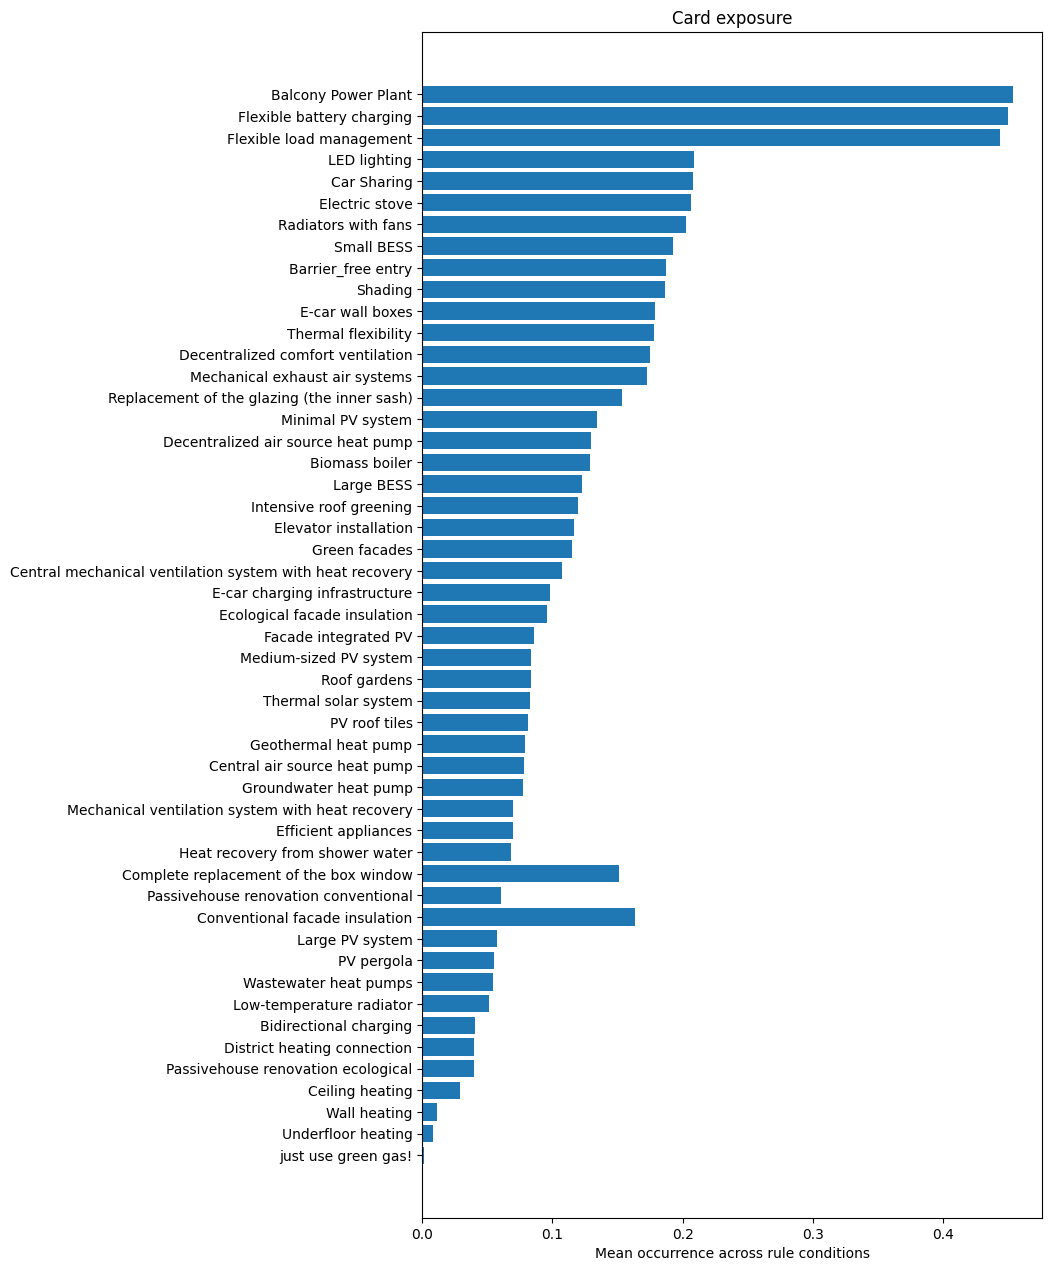

In [13]:
exposure = (
    card_robustness
    .sort_values("mean_occurrence")
)

fig, ax = plt.subplots(
    figsize=(8, max(5, 0.28 * len(exposure)))
)

ax.barh(
    exposure["label_en"],
    exposure["mean_occurrence"],
)

ax.set_xlabel("Mean occurrence across rule conditions")
ax.set_ylabel("")
ax.set_title("Card exposure")

plt.show()


## 8. VP lift and rule sensitivity

The next chart ranks cards by their **mean VP lift across rule conditions**.

The horizontal ranges are **not confidence intervals**. They show the minimum and maximum VP lift observed across the rule conditions where the lift was estimable.

Interpretation:

- entirely right of zero: consistently favourable association,
- crosses zero: effectiveness depends on gameplay rule,
- entirely left of zero: consistently unfavourable association,
- very wide range: strongly rule-sensitive card.

Cards with VP lift estimable in fewer than half of the 20 conditions are omitted from this overview.


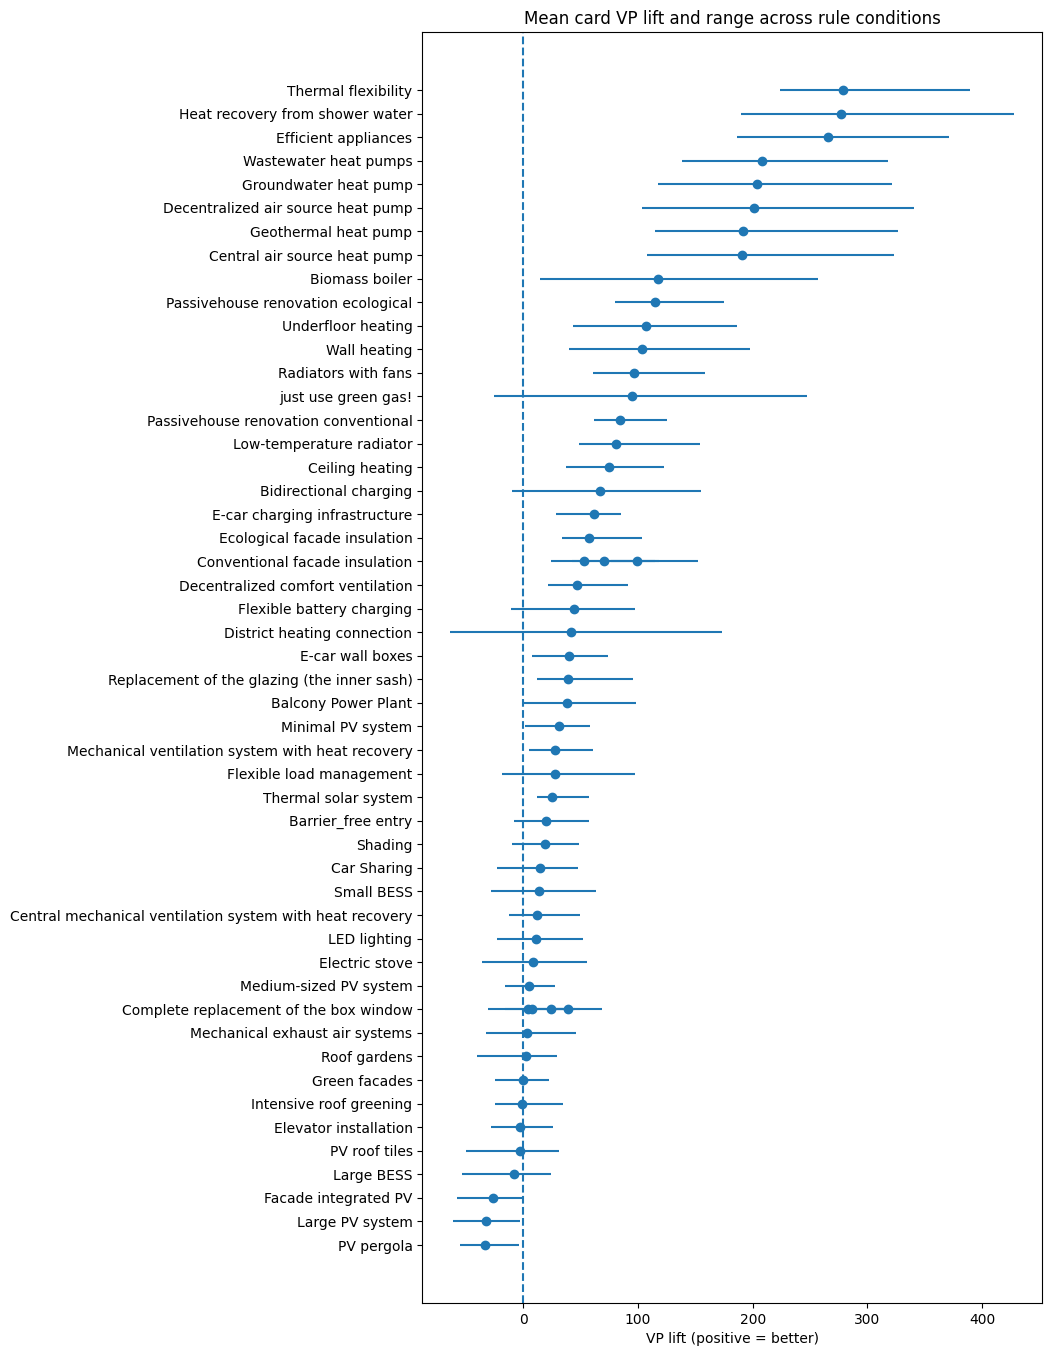

In [14]:
lift_plot = card_robustness.loc[
    card_robustness["lift_estimable"]
    >= 0.5 * card_robustness["conditions"]
].dropna(subset=["mean_vp_lift"]).copy()

lift_plot = lift_plot.sort_values("mean_vp_lift")

xerr = [
    lift_plot["mean_vp_lift"] - lift_plot["min_vp_lift"],
    lift_plot["max_vp_lift"] - lift_plot["mean_vp_lift"],
]

fig, ax = plt.subplots(
    figsize=(8, max(5, 0.3 * len(lift_plot)))
)

ax.errorbar(
    lift_plot["mean_vp_lift"],
    lift_plot["label_en"],
    xerr=xerr,
    fmt="o",
)

ax.axvline(0, linestyle="--")
ax.set_xlabel("VP lift (positive = better)")
ax.set_ylabel("")
ax.set_title("Mean card VP lift and range across rule conditions")

plt.show()


## 9. Do VP lift and elite enrichment agree?

VP lift and elite enrichment capture different aspects of performance.

A particularly convincing card lies in the **upper-right quadrant**:

- positive mean VP lift,
- mean enrichment above 1.

Cards in the other quadrants deserve closer inspection:

- positive lift but enrichment below 1: generally useful, but not characteristic of the very best games,
- negative lift but enrichment above 1: may occur in specific successful combinations or elite pathways,
- both negative: consistently weak association.

Only cards with mean occurrence of at least 2% are labelled to avoid over-interpreting extremely sparse results.


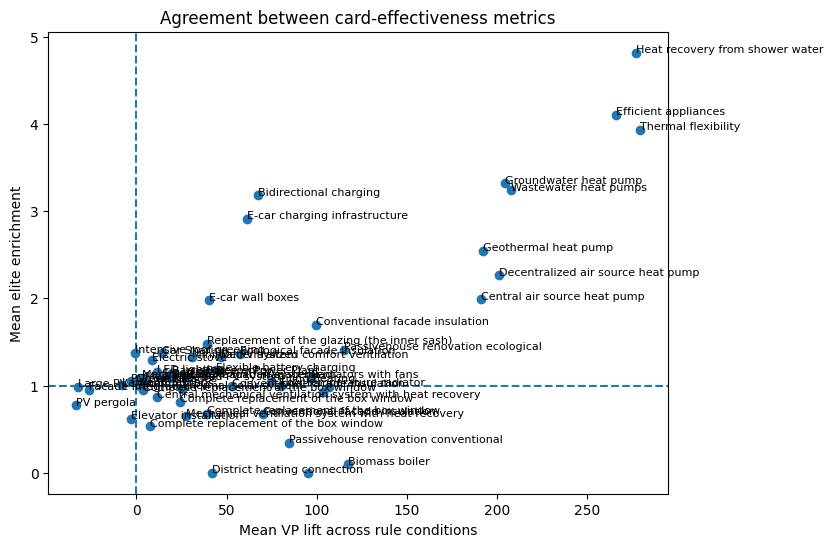

In [15]:
metric_plot = card_robustness.dropna(
    subset=["mean_vp_lift", "mean_enrichment"]
).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    metric_plot["mean_vp_lift"],
    metric_plot["mean_enrichment"],
)

ax.axvline(0, linestyle="--")
ax.axhline(1, linestyle="--")

for _, row in metric_plot.loc[
    metric_plot["mean_occurrence"] >= 0.02
].iterrows():
    ax.annotate(
        row["label_en"],
        (row["mean_vp_lift"], row["mean_enrichment"]),
        fontsize=8,
    )

ax.set_xlabel("Mean VP lift across rule conditions")
ax.set_ylabel("Mean elite enrichment")
ax.set_title("Agreement between card-effectiveness metrics")

plt.show()


## 10. Does low exposure create extreme estimates?

This diagnostic compares mean occurrence with mean VP lift.

If the strongest positive or negative VP lifts occur almost exclusively among very rare cards, the ranking is likely dominated by sparse comparisons. Those cards should be treated cautiously or investigated with more simulations.


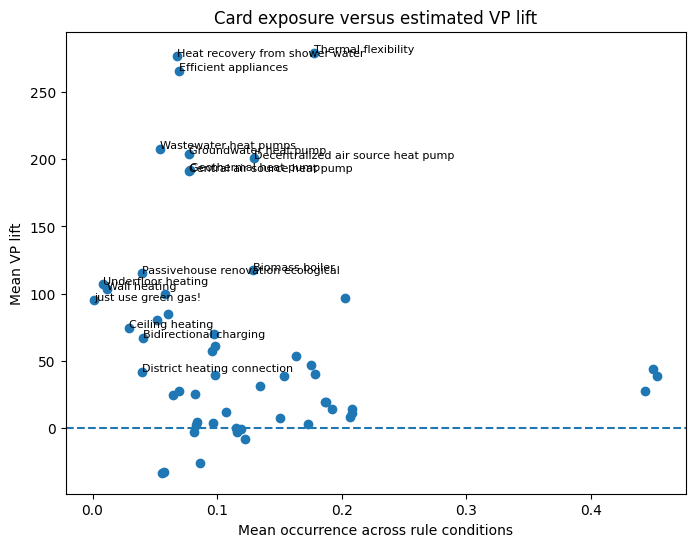

In [16]:
exposure_lift = card_robustness.dropna(
    subset=["mean_occurrence", "mean_vp_lift"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    exposure_lift["mean_occurrence"],
    exposure_lift["mean_vp_lift"],
)

ax.axhline(0, linestyle="--")

for _, row in exposure_lift.iterrows():
    if (
        row["mean_occurrence"] < 0.05
        or abs(row["mean_vp_lift"]) >= exposure_lift["mean_vp_lift"].abs().quantile(0.8)
    ):
        ax.annotate(
            row["label_en"],
            (row["mean_occurrence"], row["mean_vp_lift"]),
            fontsize=8,
        )

ax.set_xlabel("Mean occurrence across rule conditions")
ax.set_ylabel("Mean VP lift")
ax.set_title("Card exposure versus estimated VP lift")

plt.show()


## 11. Playability and random selection

`selection_rate` is calculated from all logged decision opportunities:

\[
selection\ rate =
\frac{times\ selected}
     {times\ playable}
\]

Because the strategy chooses randomly among playable cards, a high value does **not** mean that a rational player prefers the card. Instead, it indicates that the card tends to be playable when relatively few alternatives compete with it.

This makes the metric useful for diagnosing the choice structure of the game.


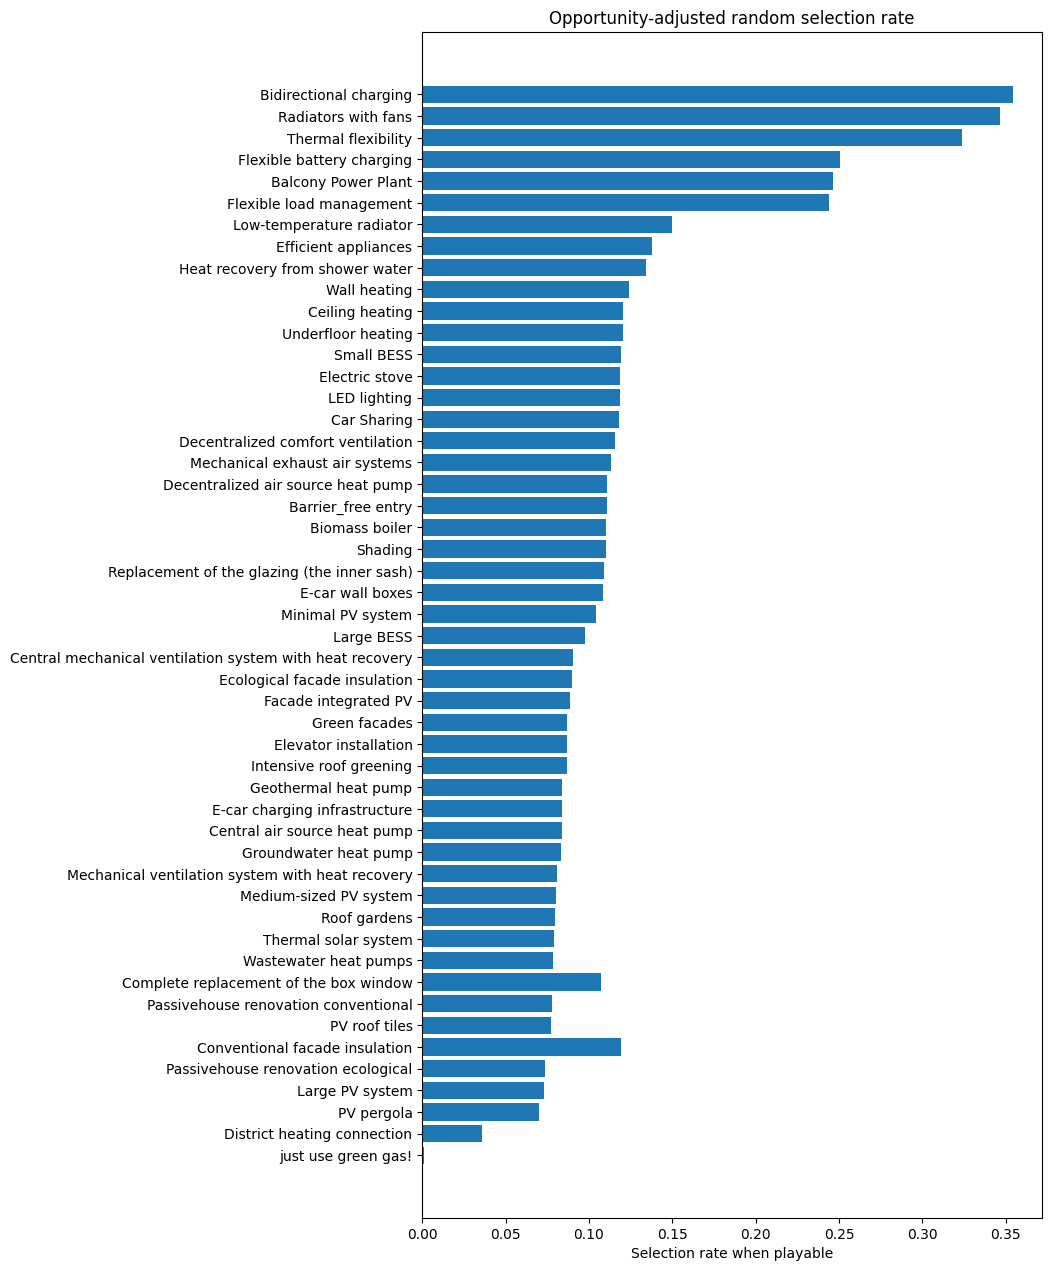

In [17]:
selection_plot = (
    card_robustness
    .dropna(subset=["selection_rate"])
    .sort_values("selection_rate")
)

fig, ax = plt.subplots(
    figsize=(8, max(5, 0.28 * len(selection_plot)))
)

ax.barh(
    selection_plot["label_en"],
    selection_plot["selection_rate"],
)

ax.set_xlabel("Selection rate when playable")
ax.set_ylabel("")
ax.set_title("Opportunity-adjusted random selection rate")

plt.show()


## 12. Timing versus effectiveness

Cards played early can affect several later scoring rounds and can enable prerequisite chains. This chart tests whether early or late timing is systematically associated with VP lift.

A pattern here does not establish causality, but it can reveal why some cards appear disproportionately valuable.


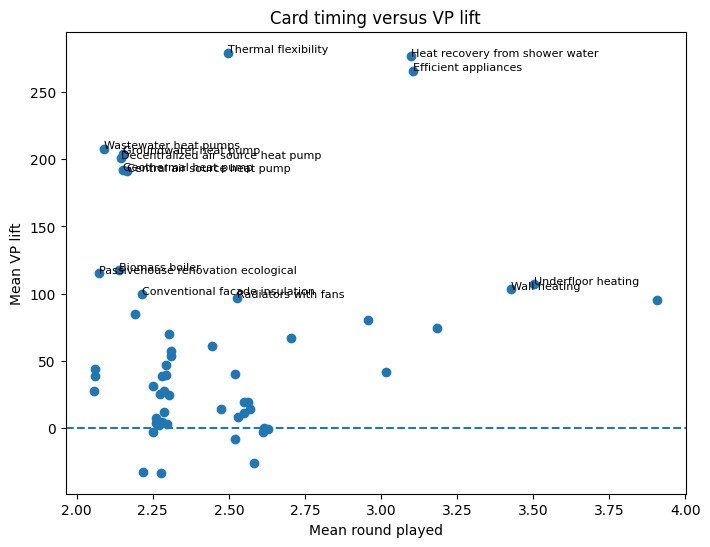

In [18]:
timing_plot = card_robustness.dropna(
    subset=["mean_round", "mean_vp_lift"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    timing_plot["mean_round"],
    timing_plot["mean_vp_lift"],
)

ax.axhline(0, linestyle="--")

for _, row in timing_plot.iterrows():
    if abs(row["mean_vp_lift"]) >= timing_plot["mean_vp_lift"].abs().quantile(0.75):
        ax.annotate(
            row["label_en"],
            (row["mean_round"], row["mean_vp_lift"]),
            fontsize=8,
        )

ax.set_xlabel("Mean round played")
ax.set_ylabel("Mean VP lift")
ax.set_title("Card timing versus VP lift")

plt.show()


## 13. Compact card-metric table

This table is the most useful overview for expert inspection. It keeps the complementary metrics together rather than reducing them to a single score.


In [19]:
card_metric_table = card_robustness[
    [
        "card",
        "label_en",
        "mean_occurrence",
        "mean_vp_lift",
        "min_vp_lift",
        "max_vp_lift",
        "positive_lift_share",
        "mean_enrichment",
        "enriched_share",
        "selection_rate",
        "mean_round",
        "playable_opportunities",
        "times_played",
    ]
].copy()

card_metric_table


,card,label_en,mean_occurrence,mean_vp_lift,min_vp_lift,max_vp_lift,positive_lift_share,mean_enrichment,enriched_share,selection_rate,mean_round,playable_opportunities,times_played
46,thermal_flexibility,Thermal flexibility,0.177892,279.192071,223.866096,389.590734,1.00,3.931437,1.00,0.323685,2.496243,90446,29276
44,shower_water_heat_recovery,Heat recovery from shower water,0.067822,276.808935,189.777155,427.920584,1.00,4.816319,1.00,0.133977,3.098228,83813,11229
16,efficient_appliances,Efficient appliances,0.069450,265.719935,186.546868,371.608423,1.00,4.105881,1.00,0.137817,3.103625,83466,11503
50,wastewater_heat_pump,Wastewater heat pumps,0.054047,207.727735,138.550155,318.133009,1.00,3.238386,1.00,0.078571,2.088768,117283,9215
28,groundwater_heat_pump,Groundwater heat pump,0.077708,204.185350,117.159289,321.369344,1.00,3.318320,1.00,0.083357,2.152636,157899,13162
13,decentralized_air_source_heat_pump,Decentralized air source heat pump,0.129951,200.912479,103.850049,340.581633,1.00,2.263491,1.00,0.111016,2.146888,196971,21867
24,geothermal_heat_pump,Geothermal heat pump,0.078611,191.977658,115.255667,326.781723,1.00,2.547161,1.00,0.084020,2.150518,158463,13314
9,central_air_source_heat_pump,Central air source heat pump,0.077800,191.086203,108.291016,323.492793,1.00,1.988377,1.00,0.083585,2.164162,157636,13176
6,biomass_boiler,Biomass boiler,0.129031,117.432118,14.988304,257.073478,1.00,0.098242,0.00,0.110015,2.139051,197219,21697
29,insulation_passivehouse_eco,Passivehouse renovation ecological,0.039410,115.062496,80.331465,174.746844,1.00,1.411527,0.95,0.073810,2.074014,91709,6769


## 14. Inspect one card across all rule conditions

Aggregate robustness can hide important interactions. Set `CARD` to any semantic `card_id` and inspect the complete condition-level results.

For one card, compare:

- occurrence,
- VP lift and its within-condition confidence interval,
- elite enrichment,
- selection rate,
- mean round.

This shows whether the card is consistently useful or only performs well for specific combinations of access rule and passing behaviour.


In [20]:
CARD = "green_gas"
c = pd.DataFrame(game_data["cards"]).loc[
    lambda df: df["card_id"] == CARD
].drop_duplicates("card_id").T

c.T

,Name,Slot/Stapel,Count,Heizsystem,Kosten,BauEmissionen,SofortCO2,Strombedarf,Stromproduktion,Stromspeicher,...,Beschreibung,description_en,card_id,label_en,Voraussetzungen Texte,Quelle,Page,requires_cards,excludes_cards,min_thermal_protection
54,Grünes Gas,Wärmeerzeugung,1,GG,2,0,0,0,0,0,...,"""Grünes Gas kann bestehende Gasheizungen weite...",NaN,green_gas,just use green gas!,NaN,https://www.klimaaktiv.at/fileadmin/Bibliothek...,32.0,{},{},0


In [21]:



card_detail = (
    card_results.loc[
        card_results["card"] == CARD,
        [
            "access_rule",
            "pass_probability",
            "occurrence",
            "elite_occurrence",
            "enrichment",
            "vp_lift",
            "vp_lift_ci_low",
            "vp_lift_ci_high",
            "selection_rate",
            "mean_round",
            "playable_opportunities",
            "times_played",
        ],
    ]
    .sort_values(["access_rule", "pass_probability"])
)

card_detail


,access_rule,pass_probability,occurrence,elite_occurrence,enrichment,vp_lift,vp_lift_ci_low,vp_lift_ci_high,selection_rate,mean_round,playable_opportunities,times_played
55,category_1x3,0.00,0.001254,0.0,0.0,106.467353,53.264888,159.669819,0.010073,4.000000,1092,11
111,category_1x3,0.10,0.001240,0.0,0.0,151.504844,102.136425,200.873264,0.009009,4.000000,1221,11
167,category_1x3,0.25,0.000662,0.0,0.0,177.972308,107.482014,248.462602,0.004376,4.000000,1371,6
223,category_1x3,0.50,0.000212,0.0,0.0,247.422538,197.253275,297.591801,0.001248,4.000000,1603,2
279,category_2x3,0.00,0.001425,0.0,0.0,77.992748,18.746276,137.239221,0.005755,3.750000,2085,12
335,category_2x3,0.10,0.001753,0.0,0.0,31.134247,-20.346763,82.615256,0.006260,3.866667,2396,15
391,category_2x3,0.25,0.001374,0.0,0.0,110.018803,56.807486,163.230120,0.004251,3.916667,2823,12
447,category_2x3,0.50,0.000873,0.0,0.0,217.909626,160.486286,275.332965,0.002347,3.875000,3409,8
502,random_10,0.00,0.001368,0.0,0.0,-19.369877,-74.004332,35.264579,0.002867,3.727273,3837,11
559,random_10,0.10,0.001226,0.0,0.0,10.331341,-33.302818,53.965500,0.002238,3.900000,4468,10


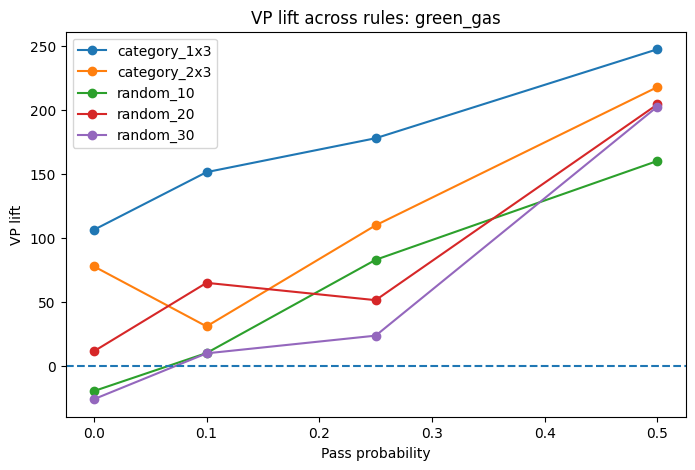

In [22]:
card_vp_lift = card_detail.pivot(
    index="pass_probability",
    columns="access_rule",
    values="vp_lift",
)

fig, ax = plt.subplots(figsize=(8, 5))

for column in card_vp_lift.columns:
    ax.plot(
        card_vp_lift.index,
        card_vp_lift[column],
        marker="o",
        label=column,
    )

ax.axhline(0, linestyle="--")
ax.set_xlabel("Pass probability")
ax.set_ylabel("VP lift")
ax.set_title(f"VP lift across rules: {CARD}")
ax.legend()

plt.show()


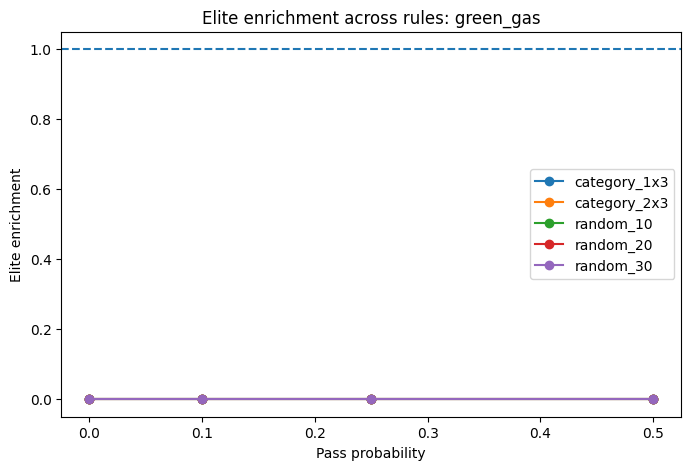

In [23]:
card_enrichment = card_detail.pivot(
    index="pass_probability",
    columns="access_rule",
    values="enrichment",
)

fig, ax = plt.subplots(figsize=(8, 5))

for column in card_enrichment.columns:
    ax.plot(
        card_enrichment.index,
        card_enrichment[column],
        marker="o",
        label=column,
    )

ax.axhline(1, linestyle="--")
ax.set_xlabel("Pass probability")
ax.set_ylabel("Elite enrichment")
ax.set_title(f"Elite enrichment across rules: {CARD}")
ax.legend()

plt.show()


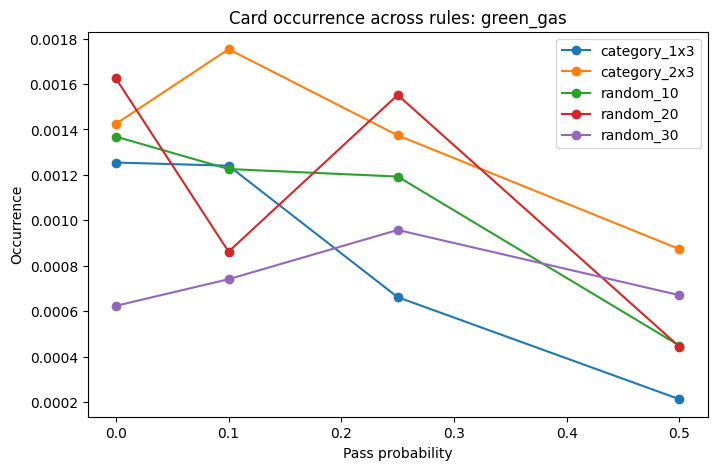

In [24]:
card_occurrence = card_detail.pivot(
    index="pass_probability",
    columns="access_rule",
    values="occurrence",
)

fig, ax = plt.subplots(figsize=(8, 5))

for column in card_occurrence.columns:
    ax.plot(
        card_occurrence.index,
        card_occurrence[column],
        marker="o",
        label=column,
    )

ax.set_xlabel("Pass probability")
ax.set_ylabel("Occurrence")
ax.set_title(f"Card occurrence across rules: {CARD}")
ax.legend()

plt.show()


In [25]:

has_card = all_games["played_cards"].apply(lambda cards: CARD in cards)

all_games.groupby(has_card)["vp"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
played_cards,,,,
False,171306,453.003701,454.0,254.769370
True,174,347.229885,337.5,91.808887


In [26]:
plays_of_card = all_plays.loc[
    all_plays["chosen_card"] == CARD
]

plays_of_card[
    [
        "experiment",
        "game_id",
        "round",
        "turn",
        "vp_before",
        "vp_after_card",
        "budget_before",
        "budget_after_card",
        "playable_cards",
    ]
]

,experiment,game_id,round,turn,vp_before,vp_after_card,budget_before,budget_after_card,playable_cards
4914,category_1x3_pass_0,949,4,0,375,375,6,4,"[decentralized_air_source_heat_pump, wastewate..."
5285,category_1x3_pass_0,1031,4,0,370,370,6,4,"[decentralized_air_source_heat_pump, geotherma..."
12416,category_1x3_pass_0,2423,4,1,360,360,5,3,"[central_air_source_heat_pump, green_gas, biom..."
13099,category_1x3_pass_0,2548,4,0,425,425,5,3,"[district_heating_connection, wastewater_heat_..."
13798,category_1x3_pass_0,2680,4,0,187,187,6,4,"[green_gas, central_air_source_heat_pump, geot..."
...,...,...,...,...,...,...,...,...,...
1416628,random_30_pass_0.5,3417,3,0,300,300,8,6,"[wastewater_heat_pump, pv_pergola, decentraliz..."
1418188,random_30_pass_0.5,3651,4,0,476,476,7,5,"[barrier_free_entry, BESS_large, pv_medium, ba..."
1439039,random_30_pass_0.5,6784,4,3,416,416,5,3,"[elevator_installation, green_gas, district_he..."
1439638,random_30_pass_0.5,6873,4,4,326,326,4,2,"[barrier_free_entry, intensive_roof_greening, ..."


In [27]:
GAME_ID = 151
EXPERIMENT = "category_1x3_pass_0"

all_plays.loc[
    (all_plays["game_id"] == GAME_ID)
    & (all_plays["experiment"] == EXPERIMENT)
].sort_values("action")

,game_id,seed,strategy,rule,draw_n,category_count,cards_per_category,pass_probability,round,turn,...,offered_cards,playable_cards,vp_before,budget_before,chosen_card,passed,vp_after_card,budget_after_card,experiment,access_rule


## 15. Interpretation checklist

For the formal investigation, interpret results in this order:

1. **Game-level rule effect:** Does broader or structured card access change final VP?
2. **Behaviour interaction:** Does that effect change with pass probability?
3. **Cards played:** Are performance changes largely explained by how many cards are selected?
4. **Card occurrence:** Is an individual card observed often enough for comparison?
5. **VP lift:** Is the card associated with lower final VP?
6. **Elite enrichment:** Is it disproportionately represented among the best games?
7. **Rule robustness:** Do these associations persist across the 20 experimental conditions?
8. **Opportunity:** When available, is the card actually selected?

A later strategy experiment can test whether these conclusions also survive deliberate technology preferences rather than random card selection.
